<a href="https://colab.research.google.com/github/RaviNautiyal/MachineLearningLabWork/blob/main/Experiment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import load_iris

# 1. KNN Implementation from scratch
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2)**2))

class KNN:
    def __init__(self, k=3):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        return np.array([self._predict(x) for x in X])

    def _predict(self, x):
        distances = [euclidean_distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# 2. Data Loading: IRIS Dataset
iris = load_iris()
X, y = iris.data, iris.target

# 3. Method 1: Square Root N
n_samples = X.shape[0]
k_sqrt_n = int(np.sqrt(n_samples))
if k_sqrt_n % 2 == 0: k_sqrt_n += 1
print(f"Total samples: {n_samples}")
print(f"K chosen by Square Root N rule: {k_sqrt_n}")

Total samples: 150
K chosen by Square Root N rule: 13


In [15]:
def calculate_accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def cross_validate(X, y, k_values, folds=5):
    indices = np.arange(len(X))
    np.random.seed(42)
    np.random.shuffle(indices)
    fold_size = len(X) // folds
    avg_scores = []

    for k in k_values:
        scores = []
        for i in range(folds):
            val_idx = indices[i*fold_size : (i+1)*fold_size]
            train_idx = np.concatenate([indices[:i*fold_size], indices[(i+1)*fold_size:]])
            model = KNN(k=k)
            model.fit(X[train_idx], y[train_idx])
            preds = model.predict(X[val_idx])
            scores.append(calculate_accuracy(y[val_idx], preds))
        avg_scores.append(np.mean(scores))
    return avg_scores

# Testing K values up to 30 for IRIS
possible_ks = list(range(1, 31, 2))
cv_scores = cross_validate(X, y, possible_ks)
optimal_k_cv = possible_ks[np.argmax(cv_scores)]
print(f"Optimal K chosen by Cross-Validation: {optimal_k_cv}")

Optimal K chosen by Cross-Validation: 13


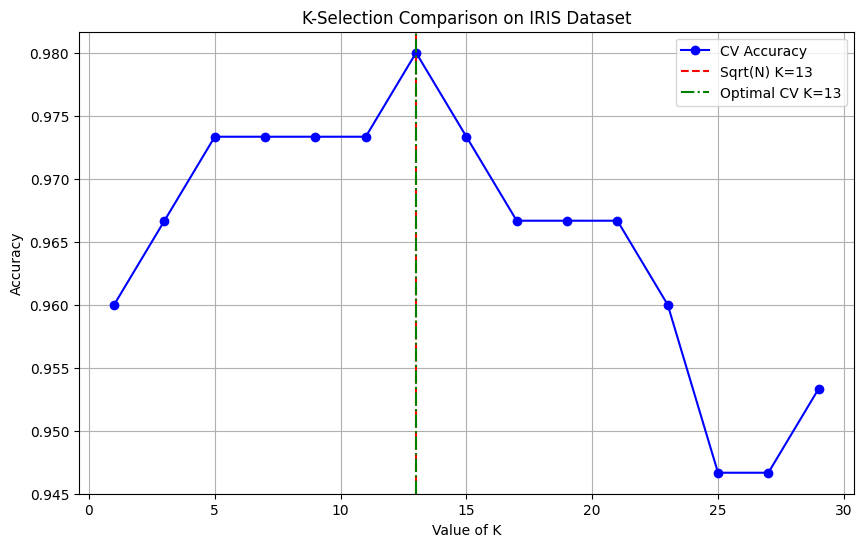

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(possible_ks, cv_scores, marker="o", color="b", label="CV Accuracy")
plt.axvline(x=k_sqrt_n, color="r", linestyle="--", label=f"Sqrt(N) K={k_sqrt_n}")
plt.axvline(x=optimal_k_cv, color="g", linestyle="-.", label=f"Optimal CV K={optimal_k_cv}")
plt.title("K-Selection Comparison on IRIS Dataset")
plt.xlabel("Value of K")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

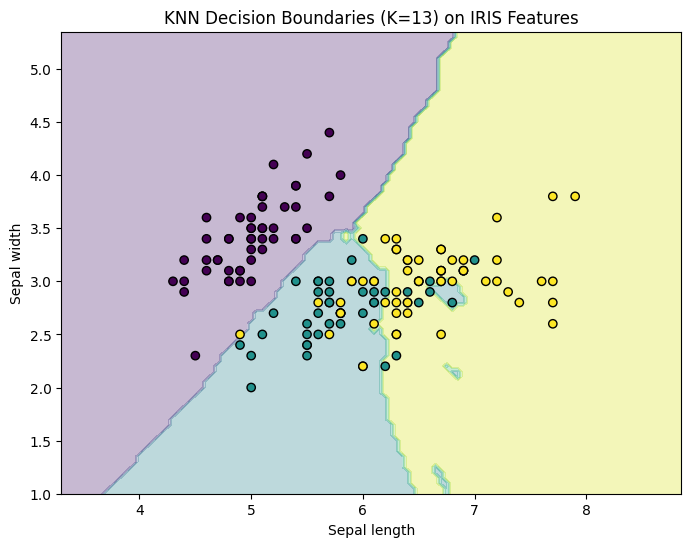

In [17]:
def plot_knn_boundaries(X, y, k, title):
    # We use only the first two features for 2D plotting
    X_plot = X[:, :2]
    h = .05  # step size in the mesh

    # Create a mesh grid
    x_min, x_max = X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1
    y_min, y_max = X_plot[:, 1].min() - 1, X_plot[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    # Initialize and fit model on 2D data
    model = KNN(k=k)
    model.fit(X_plot, y)

    # Predict across mesh grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plotting
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X_plot[:, 0], X_plot[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.title(title)
    plt.xlabel('Sepal length')
    plt.ylabel('Sepal width')
    plt.show()

# Visualize with the optimal K found (13)
plot_knn_boundaries(X, y, optimal_k_cv, f'KNN Decision Boundaries (K={optimal_k_cv}) on IRIS Features')
